In [1]:
import os, sys
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import random
assert torch.cuda.is_available()

In [2]:
# Set hyperparamters for an image
img_path = 'http://images.cocodataset.org/val2017/000000039769.jpg'
resolution = 448
patch_size = 16
num_patches = resolution // patch_size
pretrained_path = '/data/chenyinjie/CYJcode/distillation/DistillNaCLIP3/pretrained/ViT-B-16.pt' # The path of your OpenAI CLIP pretrianed weight or 'ViT-B/16'
distilled_path = '/data/chenyinjie/CYJcode/traindistill/Git_CLIP_eval/student_model.pth' # The path where you save the downloaded distilled CLIP weight
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_registers = 16

In [3]:
# Initialize Open AI ViT-B/16
from models.NACLIP.clip import load

clip_model, _ = load(
    name=pretrained_path,
    device=device,
    jit=False
)
clip_model = clip_model.to(dtype=torch.float32)
clip_model.visual.set_params(arch='reduced', attn_strategy='naclip', gaussian_std=5.0)
_ = clip_model.eval()

In [4]:
# Initialize distilled model
from models.student_CLIP import StudentCLIP

# Initialize student model
distilled_model = StudentCLIP(
        pretrained=pretrained_path,
        num_registers=16,
        patch_size=16,
        input_resolution=(448,448)
).to(device)

distilled_model = distilled_model.to(torch.float32)
distilled_model.load_state_dict(torch.load(distilled_path))
distilled_model = distilled_model.to(device)

In [5]:
# umap
import numba
import umap

def feature_umap(patch_feats, num_patches):
    assert len(patch_feats.shape) ==  2
    patch_feats = patch_feats / patch_feats.norm(dim=-1, keepdim=True)
    patch_feats_np = patch_feats.detach().cpu().numpy()
    
    @numba.njit()
    def mydist(in1, in2):
        return np.arccos(np.sum(in1*in2))
    
    transformer = umap.UMAP(
        n_components=3,
        metric=mydist)
    embedding = transformer.fit_transform(patch_feats_np)
    
    embedding_map = embedding.reshape(num_patches, num_patches, 3)
    
    normalized_map = np.zeros_like(embedding_map)
    for c in range(3):
        channel = embedding_map[:, :, c]
        c_min = channel.min()
        c_max = channel.max()
        normalized_map[:, :, c] = (channel - c_min) / (c_max - c_min + 1e-8)
    embedding_map = normalized_map
    
    embedding_tensor = torch.tensor(embedding_map, dtype=torch.float32).permute(2, 0, 1)  # [1, H, W]
    
    embedding_up = F.interpolate(embedding_tensor.unsqueeze(0), size=resolution, mode='nearest')
    embedding_up = embedding_up.squeeze()  # [n_comp, H, W]
    
    if embedding_up.shape[-1] != 3:
        embedding_up = embedding_up[:3, :, :] # :3, :, :
        embedding_up = embedding_up.permute(1, 2, 0)
    embedding_up = embedding_up.numpy()
    
    return embedding_up


from models.NACLIP.clip import tokenize

def generate_heatmap(image_embedding, text_embedding, num_patches, resolution):
    image_embedding = image_embedding.to(torch.float32)
    text_embedding = text_embedding.to(torch.float32)
    
    image_embedding_norm = image_embedding / image_embedding.norm(dim=-1, keepdim=True)
    text_embedding_norm = text_embedding / text_embedding.norm(dim=-1, keepdim=True)
    text_embedding_expanded = text_embedding_norm.unsqueeze(1)

    heatmaps = torch.bmm(image_embedding_norm, text_embedding_expanded.transpose(1, 2))
    heatmaps = heatmaps.squeeze(-1).reshape(1, num_patches, num_patches)
    heatmaps = heatmaps.cpu().unsqueeze(0)
    heatmaps = F.interpolate(heatmaps, size=(resolution, resolution), mode='nearest')
    heatmaps = heatmaps.squeeze(0).permute(1, 2, 0).numpy()
    
    return heatmaps

In [6]:
# Feedforward Pass
from torchvision.transforms import transforms
import requests
from PIL import Image

ori_img = Image.open(requests.get(url=img_path, stream=True).raw)
# If you are using your own image
# ori_img = Image.open(img_path)

img_transform = transforms.Compose([
                            transforms.Resize(resolution, interpolation=transforms.InterpolationMode.BICUBIC),
                            transforms.CenterCrop(resolution),
                            transforms.ToTensor(),
                            transforms.Normalize(mean=[0.48145466, 0.4578275, 0.40821073],
                                            std=[0.26862954, 0.26130258, 0.27577711]),
                            ])

tensor_img = img_transform(ori_img)

tensor_img = tensor_img.unsqueeze(0).to(device)

with torch.inference_mode():
    naclip_dense = clip_model.visual(tensor_img, return_all=True).detach()
    # Drop CLS token
    naclip_dense = naclip_dense[:, 1:, :]
    # print(naclip_dense.shape)
    
    clean_dense = distilled_model(tensor_img).detach()
    # Drop CLS token and register tokens
    clean_dense = clean_dense[:, 1:-num_registers, :]
    # print(clean_dense.shape)
    
# Get Umap
naclip_feat_umap = feature_umap(naclip_dense[0], num_patches)
    
clean_feat_umap = feature_umap(clean_dense[0], num_patches)
# print(clean_feat_umap.shape)

texts = []
prompt = 'a photo of cats'
texts.append(prompt)

text_input = tokenize(texts).to(device)
with torch.no_grad():
    text_features = clip_model.encode_text(text_input).detach()


# Get Heatmap
naclip_heatmap = generate_heatmap(naclip_dense, text_features, num_patches, resolution)
clean_heatmap = generate_heatmap(clean_dense, text_features, num_patches, resolution)


/data/chenyinjie/miniconda3/envs/seg_data/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/data/chenyinjie/miniconda3/envs/seg_data/lib/python3.10/site-packages/umap/umap_.py:1857: UserWarning: custom distance metric does not return gradient; inverse_transform will be unavailable. To enable using inverse_transform method, define a distance function that returns a tuple of (distance [float], gradient [np.array])
  warn(
/data/chenyinjie/miniconda3/envs/seg_data/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/data/chenyinjie/miniconda3/envs/seg_data/lib/python3.10/site-packages/umap/umap_.py:1857: UserWarning: custom distance metric does not return gradient; inverse_transform will be unavailable. To enable using inverse

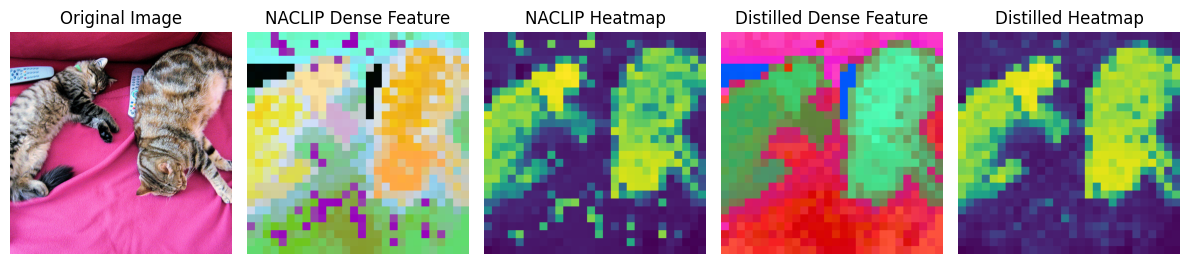

In [7]:
# Visualize all heatmaps using text as prompt
vis_transform = transforms.Compose([
                            transforms.Resize(resolution, interpolation=transforms.InterpolationMode.BICUBIC),
                            transforms.CenterCrop(resolution),
                            ])
vis_img = vis_transform(ori_img)

fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(12, 60))
axes = axes.flatten()

axes[0].imshow(vis_img)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(naclip_feat_umap)
axes[1].set_title("NACLIP Dense Feature")
axes[1].axis('off')

axes[2].imshow(naclip_heatmap)
axes[2].set_title("NACLIP Heatmap")
axes[2].axis('off')

axes[3].imshow(clean_feat_umap)
axes[3].set_title("Distilled Dense Feature")
axes[3].axis('off')

axes[4].imshow(clean_heatmap)
axes[4].set_title("Distilled Heatmap")
axes[4].axis('off')

plt.tight_layout()
plt.show()